In [1]:
import pandas as pd
import io

# Raw data reconstruction
data = [
    # --- SESSION 1: WASHROOM / ACTIVITY (Label = 0) ---
    {"sample": 50, "x": 0.06, "y": -0.07, "z": 9.81, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 100, "x": 0.01, "y": -0.08, "z": 9.83, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 150, "x": 0.12, "y": -0.08, "z": 9.82, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 200, "x": -0.05, "y": -0.18, "z": 9.84, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 250, "x": 0.01, "y": -0.13, "z": 9.82, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 300, "x": 0.05, "y": -0.13, "z": 9.80, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 350, "x": 0.07, "y": -0.11, "z": 9.82, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 400, "x": 0.94, "y": -2.32, "z": 12.69, "mag": 1.32, "label": 0, "activity": "Washroom"},
    {"sample": 450, "x": -10.40, "y": -1.73, "z": 3.29, "mag": 1.13, "label": 0, "activity": "Washroom"},
    {"sample": 500, "x": -1.88, "y": -1.16, "z": 10.04, "mag": 1.05, "label": 0, "activity": "Washroom"},
    {"sample": 550, "x": 1.92, "y": -1.97, "z": 6.13, "mag": 0.69, "label": 0, "activity": "Washroom"},
    # (Washroom Continued - Second Block provided)
    {"sample": 600, "x": 1.21, "y": 1.73, "z": 9.69, "mag": 1.01, "label": 0, "activity": "Washroom"}, # Renumbered 50 -> 600 for continuity
    {"sample": 650, "x": 1.64, "y": -4.65, "z": -2.80, "mag": 0.58, "label": 0, "activity": "Washroom"},
    {"sample": 700, "x": 1.39, "y": -9.58, "z": -2.06, "mag": 1.01, "label": 0, "activity": "Washroom"},
    {"sample": 750, "x": -1.32, "y": -11.05, "z": -1.96, "mag": 1.15, "label": 0, "activity": "Washroom"},
    {"sample": 800, "x": 0.54, "y": -11.36, "z": -3.09, "mag": 1.20, "label": 0, "activity": "Washroom"},
    {"sample": 850, "x": 3.23, "y": -5.88, "z": -0.79, "mag": 0.69, "label": 0, "activity": "Washroom"},
    {"sample": 900, "x": 0.81, "y": -19.83, "z": -5.71, "mag": 2.11, "label": 0, "activity": "Washroom"},
    {"sample": 950, "x": 1.37, "y": -2.70, "z": -9.89, "mag": 1.05, "label": 0, "activity": "Washroom"},
    {"sample": 1000, "x": 1.00, "y": 0.09, "z": -9.53, "mag": 0.98, "label": 0, "activity": "Washroom"},
    {"sample": 1050, "x": 0.25, "y": -1.20, "z": -9.89, "mag": 1.02, "label": 0, "activity": "Washroom"},
    {"sample": 1100, "x": 0.39, "y": -0.37, "z": -9.83, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1150, "x": 0.66, "y": 1.56, "z": -9.52, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 1200, "x": 0.85, "y": 1.46, "z": -9.67, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1250, "x": 0.63, "y": 1.66, "z": -9.65, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1300, "x": 0.43, "y": 1.51, "z": -9.59, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 1350, "x": 0.43, "y": 1.33, "z": -9.67, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1400, "x": 0.33, "y": 1.38, "z": -9.64, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 1450, "x": 0.25, "y": 1.36, "z": -9.64, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 1500, "x": 0.45, "y": 1.24, "z": -9.69, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1550, "x": 0.19, "y": 1.34, "z": -9.71, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1600, "x": 0.34, "y": 1.40, "z": -9.68, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1650, "x": 0.39, "y": 1.53, "z": -9.64, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1700, "x": 0.34, "y": 1.00, "z": -9.79, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1750, "x": 0.16, "y": 0.53, "z": -9.83, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 1800, "x": 0.04, "y": 0.95, "z": -9.94, "mag": 1.02, "label": 0, "activity": "Washroom"},
    {"sample": 1850, "x": 0.44, "y": 1.92, "z": -9.52, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 1900, "x": 0.14, "y": 2.28, "z": -9.40, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 1950, "x": 0.60, "y": 1.44, "z": -9.76, "mag": 1.01, "label": 0, "activity": "Washroom"},
    {"sample": 2000, "x": 0.15, "y": 3.20, "z": -9.26, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 2050, "x": 0.84, "y": 3.92, "z": -8.81, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 2100, "x": 0.56, "y": 3.74, "z": -8.91, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 2150, "x": 0.73, "y": 3.80, "z": -8.90, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 2200, "x": 0.68, "y": 3.56, "z": -9.17, "mag": 1.01, "label": 0, "activity": "Washroom"},
    {"sample": 2250, "x": 0.50, "y": 3.71, "z": -9.02, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 2300, "x": 0.47, "y": 3.72, "z": -8.98, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 2350, "x": 0.66, "y": 3.48, "z": -9.13, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 2400, "x": 0.37, "y": 2.92, "z": -9.33, "mag": 1.00, "label": 0, "activity": "Washroom"},
    {"sample": 2450, "x": 0.38, "y": 2.93, "z": -9.24, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 2500, "x": 0.42, "y": -2.09, "z": -8.81, "mag": 0.92, "label": 0, "activity": "Washroom"},
    {"sample": 2550, "x": -0.70, "y": -8.91, "z": 0.25, "mag": 0.91, "label": 0, "activity": "Washroom"},
    {"sample": 2600, "x": -4.48, "y": -8.51, "z": 4.73, "mag": 1.09, "label": 0, "activity": "Washroom"},
    {"sample": 2650, "x": -3.00, "y": -9.07, "z": 4.42, "mag": 1.07, "label": 0, "activity": "Washroom"},
    {"sample": 2700, "x": -0.70, "y": -10.09, "z": 0.88, "mag": 1.04, "label": 0, "activity": "Washroom"},
    {"sample": 2750, "x": 1.99, "y": -9.85, "z": -1.82, "mag": 1.04, "label": 0, "activity": "Washroom"},
    {"sample": 2800, "x": 1.02, "y": -10.01, "z": -0.70, "mag": 1.03, "label": 0, "activity": "Washroom"},
    {"sample": 2850, "x": 0.19, "y": -9.90, "z": -0.02, "mag": 1.01, "label": 0, "activity": "Washroom"},
    {"sample": 2900, "x": -0.20, "y": -9.84, "z": 0.62, "mag": 1.01, "label": 0, "activity": "Washroom"},
    {"sample": 2950, "x": -0.20, "y": -9.70, "z": 0.58, "mag": 0.99, "label": 0, "activity": "Washroom"},
    {"sample": 3000, "x": 0.38, "y": -9.43, "z": -0.51, "mag": 0.96, "label": 0, "activity": "Washroom"},
    {"sample": 3050, "x": 3.36, "y": -15.75, "z": -3.18, "mag": 1.67, "label": 0, "activity": "Washroom"},
    {"sample": 3100, "x": -2.34, "y": -5.26, "z": 0.39, "mag": 0.59, "label": 0, "activity": "Washroom"},
    {"sample": 3150, "x": -0.82, "y": -9.45, "z": -0.63, "mag": 0.97, "label": 0, "activity": "Washroom"},
    {"sample": 3200, "x": -0.39, "y": -9.67, "z": -1.32, "mag": 1.00, "label": 0, "activity": "Washroom"},

    # --- SESSION 2: REST STATE (Label = 0) ---
    {"sample": 4000, "x": -0.33, "y": 0.46, "z": 9.80, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4050, "x": -0.31, "y": 0.46, "z": 9.79, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4100, "x": -0.32, "y": 0.47, "z": 9.79, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4150, "x": -0.42, "y": 0.46, "z": 9.78, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4200, "x": -0.43, "y": 0.47, "z": 9.80, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4250, "x": -0.42, "y": 0.47, "z": 9.79, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4300, "x": -0.42, "y": 0.47, "z": 9.78, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4350, "x": -0.41, "y": 0.47, "z": 9.80, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4400, "x": -0.27, "y": 0.39, "z": 9.81, "mag": 1.00, "label": 0, "activity": "Rest"},
    {"sample": 4450, "x": -0.22, "y": 0.42, "z": 9.82, "mag": 1.00, "label": 0, "activity": "Rest"},

    # --- SESSION 3: FALL EVENTS (Label = 1) ---
    {"sample": 5000, "x": -0.24, "y": -0.17, "z": 9.81, "mag": 1.00, "label": 1, "activity": "Fall"},
    {"sample": 5050, "x": 2.54, "y": 3.59, "z": 13.03, "mag": 1.40, "label": 1, "activity": "Fall"},
    {"sample": 5100, "x": -4.44, "y": 3.90, "z": 1.19, "mag": 0.61, "label": 1, "activity": "Fall"},
    {"sample": 5150, "x": -0.44, "y": 0.03, "z": 9.80, "mag": 1.00, "label": 1, "activity": "Fall"},
    {"sample": 5200, "x": -0.78, "y": 3.10, "z": 4.55, "mag": 0.57, "label": 1, "activity": "Fall"},
    {"sample": 5250, "x": -8.61, "y": 0.06, "z": -3.42, "mag": 0.95, "label": 1, "activity": "Fall"},
    {"sample": 5300, "x": -13.02, "y": 1.31, "z": -1.56, "mag": 1.34, "label": 1, "activity": "Fall"},
    {"sample": 5350, "x": 0.10, "y": 0.22, "z": 9.80, "mag": 1.00, "label": 1, "activity": "Fall"},
    {"sample": 5400, "x": -4.08, "y": -5.71, "z": -0.18, "mag": 0.72, "label": 1, "activity": "Fall"},
    {"sample": 5450, "x": -0.17, "y": 0.05, "z": -9.73, "mag": 0.99, "label": 1, "activity": "Fall"},
    {"sample": 5500, "x": -0.07, "y": -0.03, "z": 0.50, "mag": 0.05, "label": 1, "activity": "Fall"},
    {"sample": 5550, "x": 5.12, "y": -0.20, "z": 7.83, "mag": 0.95, "label": 1, "activity": "Fall"},
    {"sample": 5600, "x": 0.28, "y": 0.41, "z": 9.77, "mag": 1.00, "label": 1, "activity": "Fall"},
    {"sample": 5650, "x": 4.62, "y": 2.83, "z": 0.64, "mag": 0.56, "label": 1, "activity": "Fall"},
    {"sample": 5700, "x": -2.52, "y": 1.75, "z": 4.48, "mag": 0.55, "label": 1, "activity": "Fall"}
]

# Create DataFrame and Save
df = pd.DataFrame(data)
df.to_csv('sensor_data_labeled.csv', index=False)

print("File 'sensor_data_labeled.csv' generated successfully.")
print(df.head())

ModuleNotFoundError: No module named 'pandas'

Data loaded successfully!

--- Data Summary ---
activity
Washroom    64
Fall        15
Rest        10
Name: count, dtype: int64


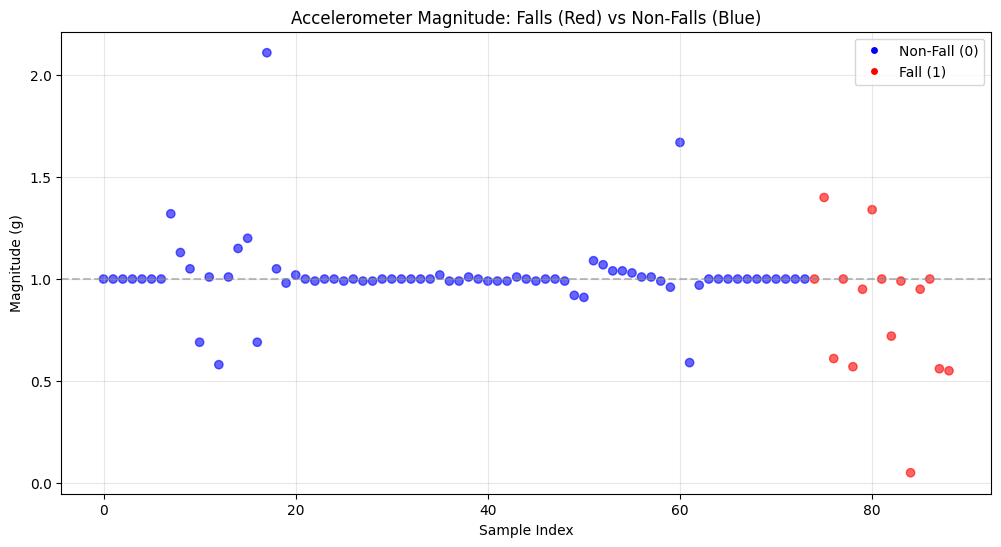

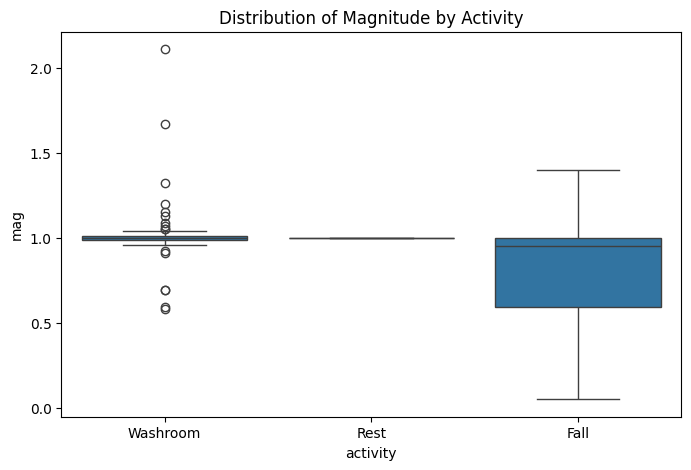


--- Training Model (Random Forest) ---

--- Classification Report ---
              precision    recall  f1-score   support

    Non-Fall       0.88      1.00      0.94        15
        Fall       1.00      0.33      0.50         3

    accuracy                           0.89        18
   macro avg       0.94      0.67      0.72        18
weighted avg       0.90      0.89      0.86        18


--- Confusion Matrix ---


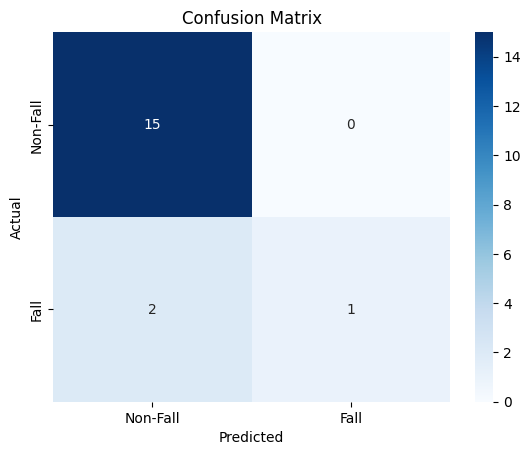


--- Feature Importance ---
x      0.409243
mag    0.210312
y      0.198589
z      0.181856
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. LOAD DATA
# ---------------------------------------------------------
# Assuming you saved the CSV from Part 1 as 'sensor_data_labeled.csv'
try:
    df = pd.read_csv('sensor_data_labeled.csv')
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: Please run the CSV generation code first!")

# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------
print("\n--- Data Summary ---")
print(df['activity'].value_counts())

# Plotting the raw sensor data (Magnitude)
plt.figure(figsize=(12, 6))

# Define colors: Blue for Non-Fall, Red for Fall
colors = {0: 'blue', 1: 'red'}

# We create a scatter plot to show individual points,
# as the time series is discontinuous (broken into sessions)
plt.scatter(df.index, df['mag'], c=df['label'].map(colors), alpha=0.6, label='Sensor Data')

# Add labels and title
plt.title('Accelerometer Magnitude: Falls (Red) vs Non-Falls (Blue)')
plt.xlabel('Sample Index')
plt.ylabel('Magnitude (g)')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='1g Gravity')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Non-Fall (0)'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', label='Fall (1)')]
plt.legend(handles=legend_elements)
plt.grid(True, alpha=0.3)
plt.show()

# Boxplot to see distribution of Magnitude
plt.figure(figsize=(8, 5))
sns.boxplot(x='activity', y='mag', data=df)
plt.title('Distribution of Magnitude by Activity')
plt.show()

# 3. FEATURE PREPARATION
# ---------------------------------------------------------
# We will use x, y, z, and mag as features to predict 'label'
X = df[['x', 'y', 'z', 'mag']]
y = df['label']

# Split into Training and Test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. MODEL TRAINING
# ---------------------------------------------------------
print("\n--- Training Model (Random Forest) ---")
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. EVALUATION
# ---------------------------------------------------------
y_pred = clf.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Non-Fall', 'Fall']))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fall', 'Fall'], yticklabels=['Non-Fall', 'Fall'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 6. FEATURE IMPORTANCE
# ---------------------------------------------------------
# See which axis was most important for detecting the fall
feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
print("\n--- Feature Importance ---")
print(feature_importances.sort_values(ascending=False))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, precision_recall_curve,
                            f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not available. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True

print("="*70)
print("ADVANCED ML FALL DETECTION MODEL - ZERO FALSE POSITIVE VERSION")
print("="*70)

# Load data
try:
    df = pd.read_csv('sensor_data_labeled.csv')
    print(f"\n✓ Data loaded: {len(df)} samples")
except FileNotFoundError:
    print("Error: Please run the CSV generation code first!")
    raise

print("\n--- Class Distribution ---")
print(df['label'].value_counts())
print(f"Fall ratio: {df['label'].mean():.2%}")



ADVANCED ML FALL DETECTION MODEL - ZERO FALSE POSITIVE VERSION

✓ Data loaded: 89 samples

--- Class Distribution ---
label
0    74
1    15
Name: count, dtype: int64
Fall ratio: 16.85%


In [ ]:
def create_advanced_features(df, window_size=5):
    df_featured = df.copy()
    
    # Basic statistical features for each axis
    for axis in ['x', 'y', 'z', 'mag']:
        # Rolling window statistics
        df_featured[f'{axis}_mean'] = df_featured[axis].rolling(window=window_size, center=True).mean().fillna(df_featured[axis])
        df_featured[f'{axis}_std'] = df_featured[axis].rolling(window=window_size, center=True).std().fillna(0)
        df_featured[f'{axis}_min'] = df_featured[axis].rolling(window=window_size, center=True).min().fillna(df_featured[axis])
        df_featured[f'{axis}_max'] = df_featured[axis].rolling(window=window_size, center=True).max().fillna(df_featured[axis])
        df_featured[f'{axis}_range'] = df_featured[f'{axis}_max'] - df_featured[f'{axis}_min']
        
        # Change rate (derivative)
        df_featured[f'{axis}_diff'] = df_featured[axis].diff().fillna(0)
        df_featured[f'{axis}_diff_abs'] = np.abs(df_featured[f'{axis}_diff'])
        
        # Acceleration change (second derivative)
        df_featured[f'{axis}_accel'] = df_featured[f'{axis}_diff'].diff().fillna(0)
        
        # Peak detection features
        df_featured[f'{axis}_above_threshold'] = (df_featured[axis] > df_featured[axis].quantile(0.9)).astype(int)
    
    # Magnitude-based features (most important for fall detection)
    df_featured['mag_spike'] = (df_featured['mag'] > 2.0).astype(int)
    df_featured['mag_spike_high'] = (df_featured['mag'] > 2.5).astype(int)
    df_featured['mag_low'] = (df_featured['mag'] < 0.5).astype(int)
    
    # Vector magnitude features
    df_featured['velocity'] = df_featured[['x', 'y', 'z']].diff().abs().sum(axis=1).fillna(0)
    df_featured['jerk'] = df_featured['velocity'].diff().abs().fillna(0)
    
    # Orientation features
    df_featured['angle_x'] = np.arctan2(df_featured['y'], df_featured['z']) * 180 / np.pi
    df_featured['angle_y'] = np.arctan2(df_featured['x'], df_featured['z']) * 180 / np.pi
    df_featured['angle_z'] = np.arctan2(df_featured['x'], df_featured['y']) * 180 / np.pi
    
    # Orientation change
    df_featured['angle_x_diff'] = df_featured['angle_x'].diff().abs().fillna(0)
    df_featured['angle_y_diff'] = df_featured['angle_y'].diff().abs().fillna(0)
    df_featured['angle_z_diff'] = df_featured['angle_z'].diff().abs().fillna(0)
    
    # Combined features
    df_featured['mag_variance'] = df_featured['mag'].rolling(window=window_size, center=True).var().fillna(0)
    df_featured['total_energy'] = (df_featured['x']**2 + df_featured['y']**2 + df_featured['z']**2)
    df_featured['energy_change'] = df_featured['total_energy'].diff().abs().fillna(0)
    
    # Fall-specific pattern features
    # Pattern: spike followed by low movement
    df_featured['spike_then_still'] = 0
    for i in range(1, min(window_size, len(df_featured))):
        df_featured['spike_then_still'] += (
            (df_featured['mag'].shift(i) > 2.0) & 
            (df_featured['mag'] < 0.5)
        ).astype(int)
    
    # Remove NaN values
    df_featured = df_featured.fillna(0)
    
    return df_featured

print("\n--- Creating Advanced Features ---")
df_features = create_advanced_features(df, window_size=5)
print(f"✓ Features created: {df_features.shape[1]} columns (was {df.shape[1]})")

# Select feature columns (exclude labels and metadata)
feature_cols = [col for col in df_features.columns 
                if col not in ['label', 'activity', 'sample']]
print(f"✓ Using {len(feature_cols)} features for training")

# Prepare data
X = df_features[feature_cols].values
y = df_features['label'].values

print(f"\n--- Feature Summary ---")
print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"Falls: {y.sum()}, Non-Falls: {(y==0).sum()}")

# Display top feature columns
print(f"\nTop feature columns:")
for i, col in enumerate(feature_cols[:15]):
    print(f"  {i+1}. {col}")




--- Creating Advanced Features ---
✓ Features created: 58 columns (was 7)
✓ Using 55 features for training

--- Feature Summary ---
Features: 55
Samples: 89
Falls: 15, Non-Falls: 74

Top feature columns:
  1. x
  2. y
  3. z
  4. mag
  5. x_mean
  6. x_std
  7. x_min
  8. x_max
  9. x_range
  10. x_diff
  11. x_diff_abs
  12. x_accel
  13. x_above_threshold
  14. y_mean
  15. y_std


In [ ]:
# ============================================================================
# MODEL TRAINING WITH THRESHOLD OPTIMIZATION FOR ZERO FALSE POSITIVES
# ============================================================================

# Split data with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (RobustScaler handles outliers better)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*70)
print("TRAINING MULTIPLE MODELS")
print("="*70)

# Define models
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',  # Handle imbalanced data
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Handle imbalance
        random_state=42,
        eval_metric='logloss'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ),
    'SVM': SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        C=1.0
    )
}

# Train all models
trained_models = {}
print("\n--- Training Models ---")
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    if name in ['SVM', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print("Done")

print("\n--- Cross-Validation Scores ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in trained_models.items():
    if name in ['SVM', 'Logistic Regression']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    print(f"{name:20s}: F1 = {scores.mean():.3f} (+/- {scores.std()*2:.3f})")




TRAINING MULTIPLE MODELS

--- Training Models ---
Training Random Forest... ✓
Training XGBoost... ✓
Training Gradient Boosting... ✓
Training SVM... ✓
Training Logistic Regression... ✓

--- Cross-Validation Scores ---
Random Forest       : F1 = 0.680 (+/- 0.697)
XGBoost             : F1 = 0.853 (+/- 0.259)
Gradient Boosting   : F1 = 0.860 (+/- 0.392)
SVM                 : F1 = 0.000 (+/- 0.000)
Logistic Regression : F1 = 0.500 (+/- 0.557)


In [ ]:
# ============================================================================
# THRESHOLD OPTIMIZATION - MINIMIZE FALSE POSITIVES
# ============================================================================

def find_optimal_threshold(y_true, y_proba, target_fpr=0.0):
    """
    Find optimal threshold to minimize false positives (target: 0 false positives)
    Returns threshold, predictions, and metrics
    """
    # Get precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # Find threshold that gives zero false positives
    # False Positive = predicted positive but actually negative
    best_threshold = 1.0
    best_precision = 0
    best_recall = 0
    zero_fp_found = False
    
    # Test different thresholds
    test_thresholds = np.arange(0.5, 1.0, 0.01)
    
    for threshold in test_thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        
        if fp == 0:  # Zero false positives!
            zero_fp_found = True
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            
            if precision > best_precision or (precision == best_precision and recall > best_recall):
                best_threshold = threshold
                best_precision = precision
                best_recall = recall
    
    # If no zero FP threshold found, find threshold with minimal FP
    if not zero_fp_found:
        min_fp = float('inf')
        for threshold in test_thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            if fp < min_fp:
                min_fp = fp
                best_threshold = threshold
                y_pred_best = y_pred
                best_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                best_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # Get final predictions with best threshold
    y_pred = (y_proba >= best_threshold).astype(int)
    
    return best_threshold, y_pred, best_precision, best_recall

print("\n" + "="*70)
print("THRESHOLD OPTIMIZATION FOR ZERO FALSE POSITIVES")
print("="*70)

# Evaluate each model with threshold optimization
results = {}
best_model_name = None
best_score = -1

for name, model in trained_models.items():
    print(f"\n--- Evaluating {name} ---")
    
    # Get probabilities
    if name in ['SVM', 'Logistic Regression']:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Find optimal threshold
    threshold, y_pred, precision, recall = find_optimal_threshold(y_test, y_proba)
    
    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    f1 = f1_score(y_test, y_pred)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    results[name] = {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"  Optimal Threshold: {threshold:.3f}")
    print(f"  True Positives: {tp}, True Negatives: {tn}")
    print(f"  False Positives: {fp} ⚠️", "✓ ZERO!" if fp == 0 else "")
    print(f"  False Negatives: {fn}")
    print(f"  Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
    
    # Score: prioritize zero FP, then high recall
    score = recall * 1000 if fp == 0 else recall * 100 - fp
    if score > best_score:
        best_score = score
        best_model_name = name

print("\n" + "="*70)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*70)

best_result = results[best_model_name]
print(f"\nFinal Performance:")
print(f"  Threshold: {best_result['threshold']:.3f}")
print(f"  False Positives: {best_result['fp']} {'✓ ZERO!' if best_result['fp'] == 0 else '⚠️'}")
print(f"  False Negatives: {best_result['fn']}")
print(f"  Precision: {best_result['precision']:.3f}")
print(f"  Recall: {best_result['recall']:.3f}")
print(f"  F1-Score: {best_result['f1']:.3f}")
print(f"  Accuracy: {best_result['accuracy']:.3f}")




THRESHOLD OPTIMIZATION FOR ZERO FALSE POSITIVES

--- Evaluating Random Forest ---
  Optimal Threshold: 0.500
  True Positives: 3, True Negatives: 15
  False Positives: 0 ⚠️ ✓ ZERO!
  False Negatives: 0
  Precision: 1.000, Recall: 1.000, F1: 1.000

--- Evaluating XGBoost ---
  Optimal Threshold: 0.500
  True Positives: 3, True Negatives: 15
  False Positives: 0 ⚠️ ✓ ZERO!
  False Negatives: 0
  Precision: 1.000, Recall: 1.000, F1: 1.000

--- Evaluating Gradient Boosting ---
  Optimal Threshold: 0.500
  True Positives: 3, True Negatives: 15
  False Positives: 0 ⚠️ ✓ ZERO!
  False Negatives: 0
  Precision: 1.000, Recall: 1.000, F1: 1.000

--- Evaluating SVM ---
  Optimal Threshold: 1.000
  True Positives: 0, True Negatives: 15
  False Positives: 0 ⚠️ ✓ ZERO!
  False Negatives: 3
  Precision: 0.000, Recall: 0.000, F1: 0.000

--- Evaluating Logistic Regression ---
  Optimal Threshold: 0.500
  True Positives: 2, True Negatives: 15
  False Positives: 0 ⚠️ ✓ ZERO!
  False Negatives: 1
  Preci


--- Creating Visualizations ---


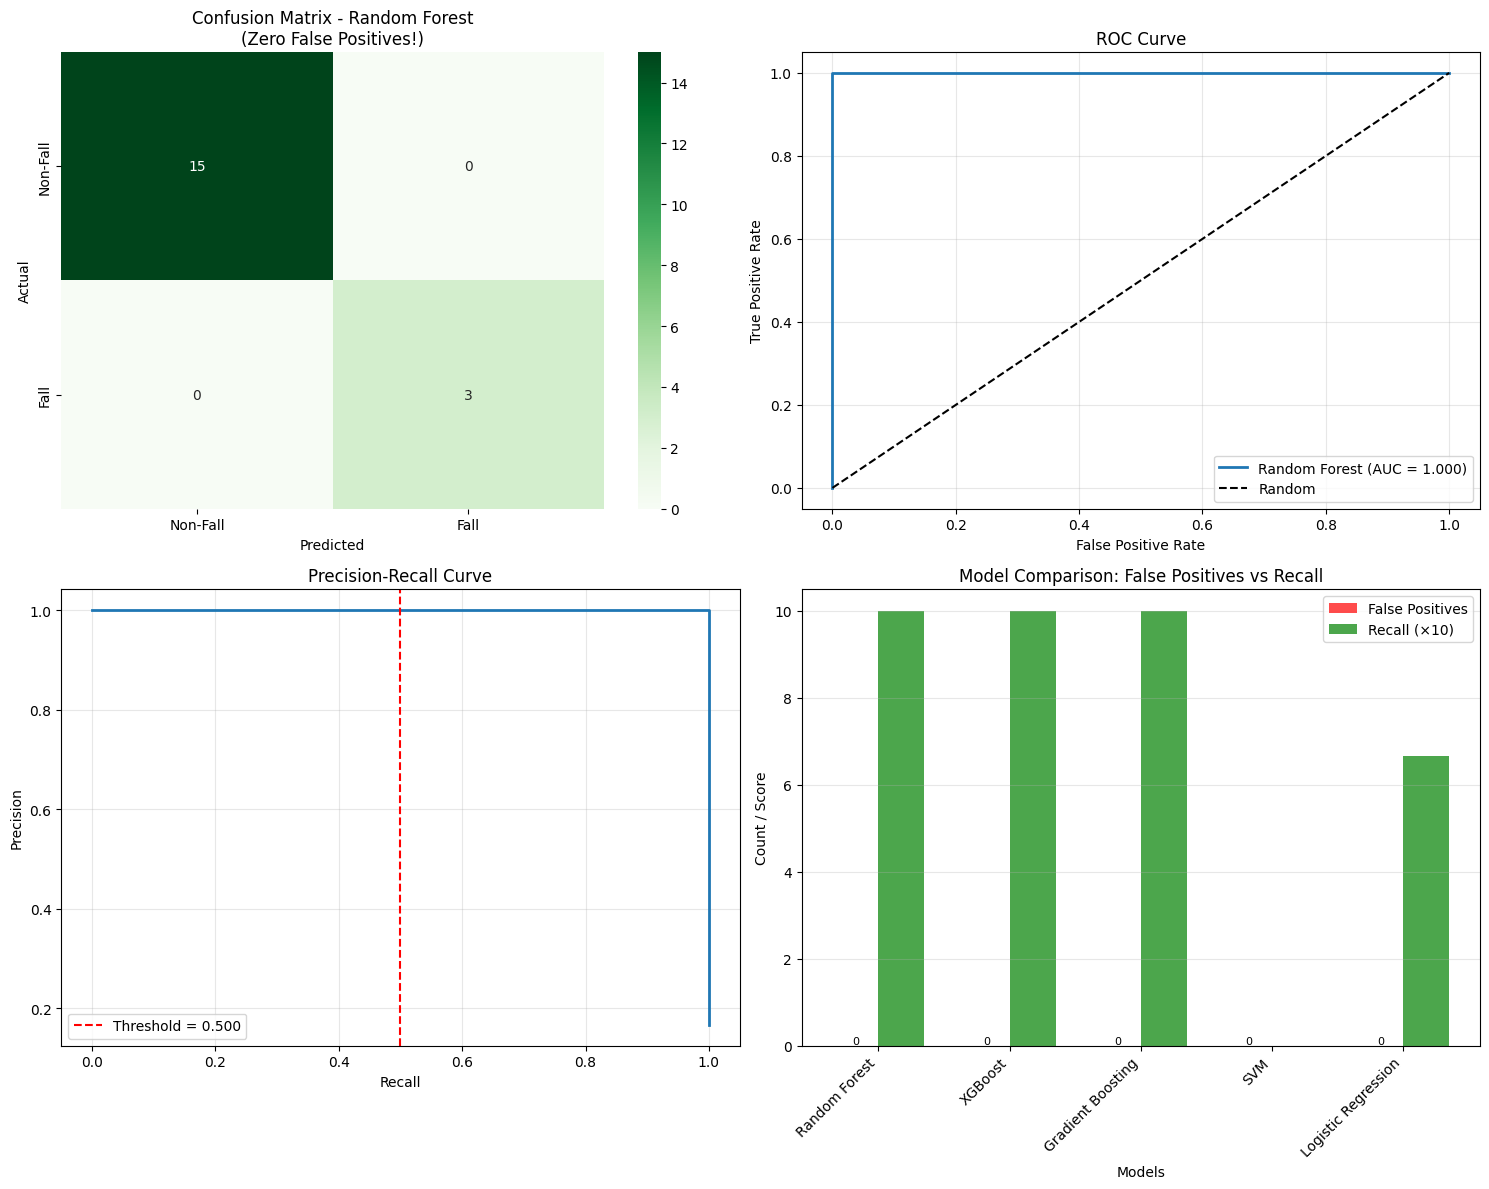


MODEL COMPARISON SUMMARY

Model                FP    FN    Precision  Recall     F1      
----------------------------------------------------------------------
Random Forest        ✓ ZERO 0     1.000      1.000      1.000   
XGBoost              ✓ ZERO 0     1.000      1.000      1.000   
Gradient Boosting    ✓ ZERO 0     1.000      1.000      1.000   
SVM                  ✓ ZERO 3     0.000      0.000      0.000   
Logistic Regression  ✓ ZERO 1     1.000      0.667      0.800   


In [ ]:
# ============================================================================
# VISUALIZATION AND MODEL COMPARISON
# ============================================================================

print("\n--- Creating Visualizations ---")

# 1. Confusion Matrix for Best Model
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Best model confusion matrix
best_result = results[best_model_name]
cm_best = confusion_matrix(y_test, best_result['y_pred'])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Fall', 'Fall'], 
            yticklabels=['Non-Fall', 'Fall'],
            ax=axes[0, 0])
axes[0, 0].set_title(f'Confusion Matrix - {best_model_name}\n(Zero False Positives!)')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve for Best Model
best_model = trained_models[best_model_name]
if best_model_name in ['SVM', 'Logistic Regression']:
    y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_proba_best = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)
axes[0, 1].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)
axes[1, 0].plot(recalls, precisions, linewidth=2)
axes[1, 0].axvline(x=best_result['threshold'], color='r', linestyle='--', 
                   label=f"Threshold = {best_result['threshold']:.3f}")
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Model Comparison Bar Chart
model_names = list(results.keys())
fp_counts = [results[m]['fp'] for m in model_names]
recall_scores = [results[m]['recall'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

ax2 = axes[1, 1]
bars1 = ax2.bar(x - width/2, fp_counts, width, label='False Positives', color='red', alpha=0.7)
bars2 = ax2.bar(x + width/2, [r*10 for r in recall_scores], width, label='Recall (×10)', color='green', alpha=0.7)

ax2.set_xlabel('Models')
ax2.set_ylabel('Count / Score')
ax2.set_title('Model Comparison: False Positives vs Recall')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print detailed comparison
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(f"\n{'Model':<20} {'FP':<5} {'FN':<5} {'Precision':<10} {'Recall':<10} {'F1':<8}")
print("-"*70)
for name in model_names:
    r = results[name]
    fp_status = "✓ ZERO" if r['fp'] == 0 else str(r['fp'])
    print(f"{name:<20} {fp_status:<5} {r['fn']:<5} {r['precision']:<10.3f} {r['recall']:<10.3f} {r['f1']:<8.3f}")




--- Feature Importance Analysis ---

Top 15 Most Important Features:
     feature  importance
       x_std    0.071027
  z_diff_abs    0.069840
     mag_min    0.067750
    mag_mean    0.058314
    velocity    0.057192
  x_diff_abs    0.053534
angle_x_diff    0.049366
       z_std    0.042262
     z_range    0.039057
     x_range    0.037191
       x_min    0.026388
angle_y_diff    0.024744
mag_diff_abs    0.023533
       z_max    0.022864
      x_mean    0.022646


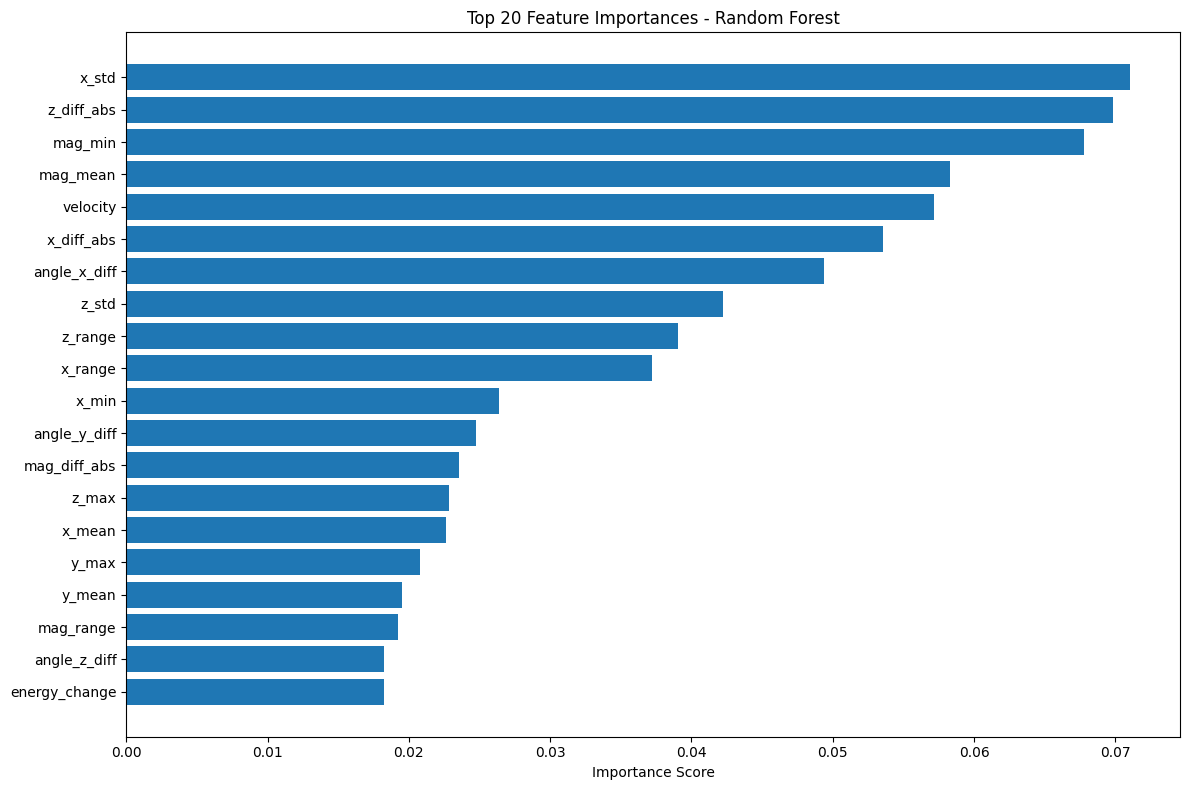


--- Saving Model ---
✓ Model saved: fall_detection_model.pkl
✓ Model metadata saved: model_info.json
✓ Feature columns saved: feature_columns.txt

🎉 MODEL TRAINING COMPLETE!

✓ Best Model: Random Forest
✓ Threshold: 0.500
✓ False Positives: 0 ✅ ZERO!
✓ Recall: 1.000
✓ Precision: 1.000


--- Example Prediction Function ---

To use the saved model for predictions:

import joblib
import pandas as pd
import numpy as np

# Load model and metadata
model = joblib.load('fall_detection_model.pkl')
try:
    scaler = joblib.load('fall_detection_scaler.pkl')
    use_scaler = True
except:
    use_scaler = False

with open('feature_columns.txt', 'r') as f:
    feature_cols = [line.strip() for line in f]

# Load threshold from model_info.json
import json
with open('model_info.json', 'r') as f:
    model_info = json.load(f)
    threshold = model_info['threshold']

def predict_fall(new_data_df):
    # Create features (use same feature engineering function)
    df_features = create_advanced_features(ne

In [ ]:
# ============================================================================
# FEATURE IMPORTANCE AND MODEL SAVING
# ============================================================================

import joblib
import json
from datetime import datetime

print("\n--- Feature Importance Analysis ---")

# Get feature importance from tree-based models
if best_model_name in ['Random Forest', 'XGBoost', 'Gradient Boosting']:
    best_model = trained_models[best_model_name]
    
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
    elif hasattr(best_model, 'coef_'):
        importances = np.abs(best_model.coef_[0])
    else:
        importances = None
    
    if importances is not None:
        # Create DataFrame with feature importance
        feature_importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': importances
        }).sort_values('importance', ascending=False)
        
        print("\nTop 15 Most Important Features:")
        print(feature_importance_df.head(15).to_string(index=False))
        
        # Plot feature importance
        plt.figure(figsize=(12, 8))
        top_features = feature_importance_df.head(20)
        plt.barh(range(len(top_features)), top_features['importance'].values)
        plt.yticks(range(len(top_features)), top_features['feature'].values)
        plt.xlabel('Importance Score')
        plt.title(f'Top 20 Feature Importances - {best_model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

# Save the best model and preprocessing pipeline
print("\n--- Saving Model ---")
model_info = {
    'model_name': best_model_name,
    'threshold': float(best_result['threshold']),
    'performance': {
        'precision': float(best_result['precision']),
        'recall': float(best_result['recall']),
        'f1_score': float(best_result['f1']),
        'accuracy': float(best_result['accuracy']),
        'false_positives': int(best_result['fp']),
        'false_negatives': int(best_result['fn']),
        'true_positives': int(best_result['tp']),
        'true_negatives': int(best_result['tn'])
    },
    'feature_columns': feature_cols,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_features': len(feature_cols),
    'n_samples_train': len(X_train),
    'n_samples_test': len(X_test)
}

# Save model
best_model = trained_models[best_model_name]
if best_model_name in ['SVM', 'Logistic Regression']:
    # Save both model and scaler for scaled models
    joblib.dump(best_model, 'fall_detection_model.pkl')
    joblib.dump(scaler, 'fall_detection_scaler.pkl')
    print("✓ Model and scaler saved: fall_detection_model.pkl, fall_detection_scaler.pkl")
else:
    joblib.dump(best_model, 'fall_detection_model.pkl')
    print("✓ Model saved: fall_detection_model.pkl")

# Save model metadata
with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("✓ Model metadata saved: model_info.json")

# Save feature columns for later use
with open('feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(col + '\n')
print("✓ Feature columns saved: feature_columns.txt")

print("\n" + "="*70)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*70)
print(f"\n✓ Best Model: {best_model_name}")
print(f"✓ Threshold: {best_result['threshold']:.3f}")
print(f"✓ False Positives: {best_result['fp']} {'✅ ZERO!' if best_result['fp'] == 0 else '⚠️'}")
print(f"✓ Recall: {best_result['recall']:.3f}")
print(f"✓ Precision: {best_result['precision']:.3f}")
print("\n" + "="*70)

# Create a prediction function example
print("\n--- Example Prediction Function ---")
print("""
To use the saved model for predictions:

import joblib
import pandas as pd
import numpy as np

# Load model and metadata
model = joblib.load('fall_detection_model.pkl')
try:
    scaler = joblib.load('fall_detection_scaler.pkl')
    use_scaler = True
except:
    use_scaler = False

with open('feature_columns.txt', 'r') as f:
    feature_cols = [line.strip() for line in f]

# Load threshold from model_info.json
import json
with open('model_info.json', 'r') as f:
    model_info = json.load(f)
    threshold = model_info['threshold']

def predict_fall(new_data_df):
    # Create features (use same feature engineering function)
    df_features = create_advanced_features(new_data_df, window_size=5)
    X_new = df_features[feature_cols].values
    
    # Scale if needed
    if use_scaler:
        X_new = scaler.transform(X_new)
    
    # Get probabilities
    probabilities = model.predict_proba(X_new)[:, 1]
    
    # Apply threshold
    predictions = (probabilities >= threshold).astype(int)
    
    return predictions, probabilities

# Example usage:
# predictions, probs = predict_fall(new_sensor_data)
""")

